# CSET343 - Lab Experiment 1


In [ ]:
# ---------- 0. ENVIRONMENT SETUP ----------
!pip install -q ucimlrepo wfdb pydicom nltk

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.4 MB/s eta 0:00:00


In [ ]:
print("PART 1: TABULAR DATA - UCI CLEVELAND HEART DISEASE DATASET")
print("="*70)

from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("\nDataset metadata:")
print(f"  Name: {heart_disease.metadata['name']}")
print(f"  Instances: {heart_disease.metadata['num_instances']}")
print(f"  Features: {heart_disease.metadata['num_features']}")

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nFirst 5 rows of X:")
print(X.head())

print("\nData types:")
print(X.dtypes)

print("\nMissing values per column:")
print(X.isnull().sum())

print("\nOriginal target ('num') distribution (0=no disease, 1-4=increasing severity):")
print(y["num"].value_counts().sort_index())

PART 1: TABULAR DATA - UCI CLEVELAND HEART DISEASE DATASET

Dataset metadata:
  Name: Heart Disease
  Instances: 303
  Features: 13

X shape: (303, 13)
y shape: (303, 1)

First 5 rows of X:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64


In [ ]:
# Binarize target: 0 = no disease, 1 = disease present (any severity)
y["num"] = (y["num"] > 0).astype(int)
print("\nBinarized target distribution:")
print(y["num"].value_counts())


Binarized target distribution:
num
0    164
1    139
Name: count, dtype: int64


In [ ]:
# Impute missing values
X["ca"] = X["ca"].fillna(X["ca"].median())
X["thal"] = X["thal"].fillna(X["thal"].median())
print("\nMissing values after imputation:")
print(X.isnull().sum())

df = X.copy()
df["target"] = y["num"]

print("\nSummary statistics:")
print(df.describe())


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Summary statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg   

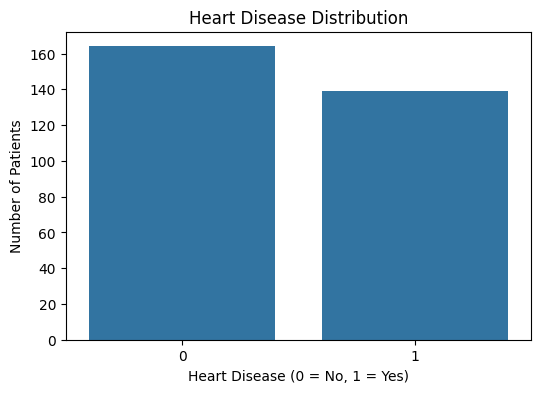

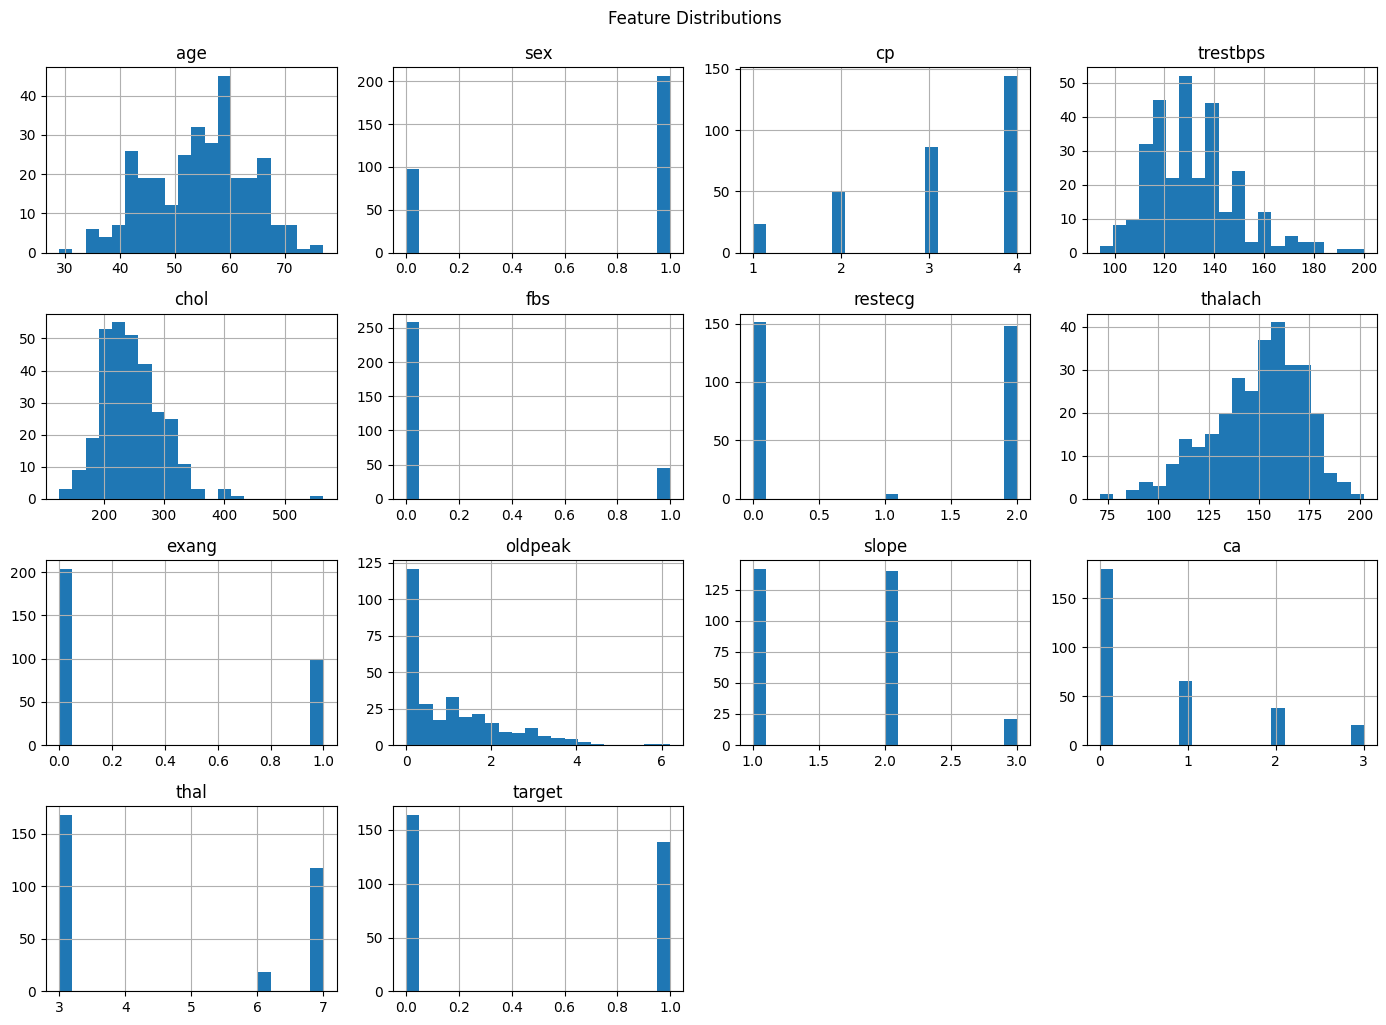

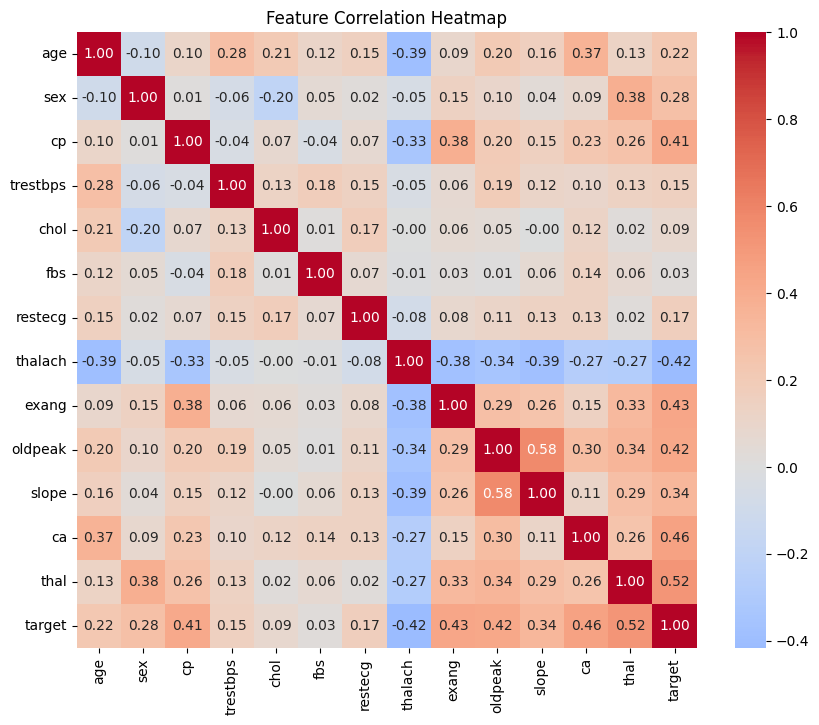

In [ ]:
# EDA plots
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


LOGISTIC REGRESSION RESULTS

Accuracy : 0.8689 (86.89%)
ROC-AUC  : 0.9513

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



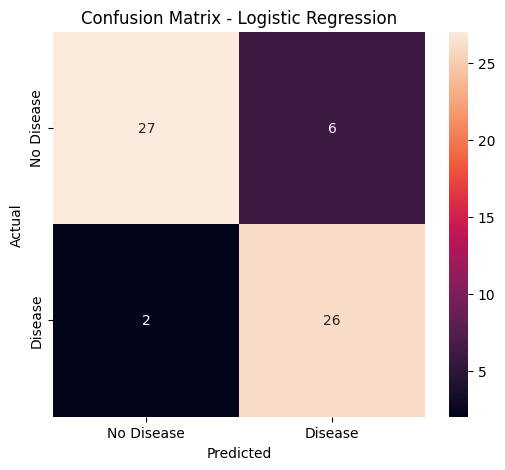

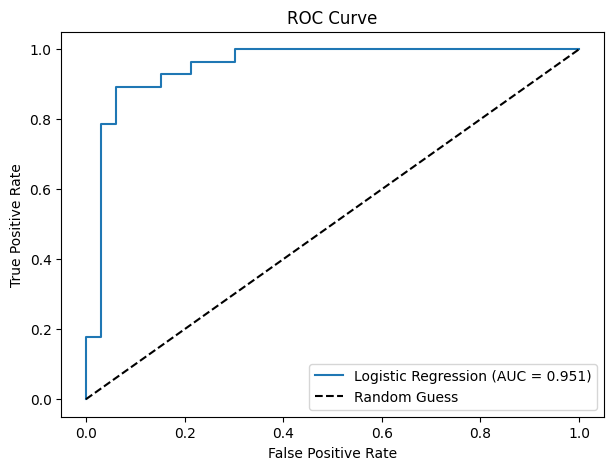

In [ ]:
# Baseline classifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

X_feat = df.drop("target", axis=1)
y_target = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target, test_size=0.20, random_state=42, stratify=y_target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"\nAccuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
print("PART 2: SIGNAL DATA - MIT-BIH ARRHYTHMIA DATABASE (ECG)")
print("="*70)

import wfdb

record_name = "100"
record = wfdb.rdrecord(record_name, pn_dir="mitdb")
annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

fs = record.fs
signal = record.p_signal[:, 0]  # channel 0 (MLII lead)

print(f"\nRecord: {record_name}")
print(f"Sampling frequency: {fs} Hz")
print(f"Signal length: {len(signal)} samples ({len(signal)/fs:.1f} seconds)")
print(f"Number of channels: {record.n_sig} -> {record.sig_name}")
print(f"Number of annotated beats: {len(annotation.sample)}")

PART 2: SIGNAL DATA - MIT-BIH ARRHYTHMIA DATABASE (ECG)

Record: 100
Sampling frequency: 360 Hz
Signal length: 650000 samples (1805.6 seconds)
Number of channels: 2 -> ['MLII', 'V5']
Number of annotated beats: 2274


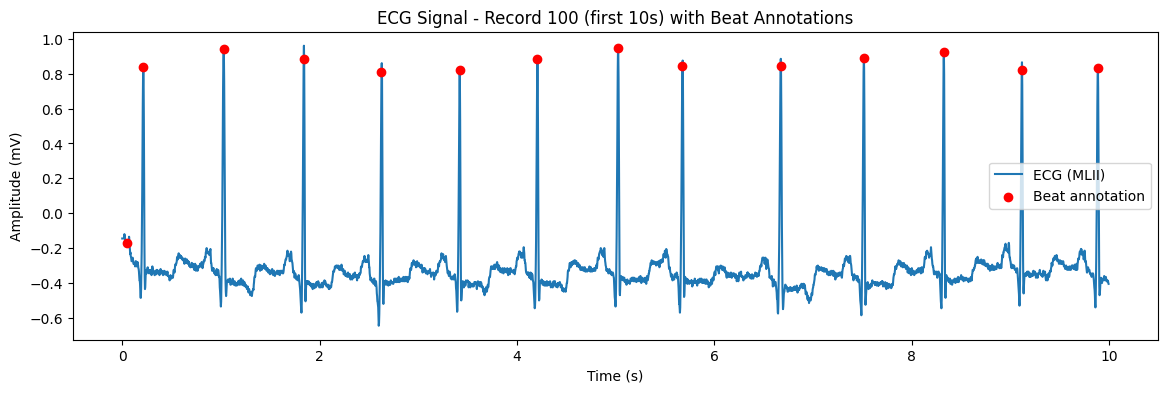

In [ ]:
# Plot a 10-second segment with beat annotations
segment_sec = 10
n_samples = segment_sec * fs
t = np.arange(n_samples) / fs

ann_in_segment = annotation.sample[annotation.sample < n_samples]

plt.figure(figsize=(14, 4))
plt.plot(t, signal[:n_samples], label=f"ECG ({record.sig_name[0]})")
plt.scatter(ann_in_segment / fs, signal[ann_in_segment], color="red",
            marker="o", label="Beat annotation", zorder=5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"ECG Signal - Record {record_name} (first {segment_sec}s) with Beat Annotations")
plt.legend()
plt.show()


In [ ]:

# Basic heart-rate / HRV statistics from R-R intervals
rr_intervals_sec = np.diff(annotation.sample) / fs
rr_intervals_ms = rr_intervals_sec * 1000
heart_rate_bpm = 60 / rr_intervals_sec

print("\nHeart Rate / HRV statistics:")
print(f"  Mean RR interval : {rr_intervals_ms.mean():.1f} ms")
print(f"  SDNN (RR std dev): {rr_intervals_ms.std():.1f} ms")
print(f"  Mean heart rate  : {heart_rate_bpm.mean():.1f} bpm")
print(f"  Min / Max HR     : {heart_rate_bpm.min():.1f} / {heart_rate_bpm.max():.1f} bpm")


Heart Rate / HRV statistics:
  Mean RR interval : 794.3 ms
  SDNN (RR std dev): 50.6 ms
  Mean heart rate  : 75.9 bpm
  Min / Max HR     : 53.1 / 366.1 bpm


PART 3: TEXTUAL DATA - SYNTHETIC CLINICAL NOTE

Original clinical note:
Patient is a 58-year-old male presenting with intermittent chest pain
radiating to the left arm, associated with shortness of breath and
mild diaphoresis. Pain worsens with exertion and improves with rest.
Patient reports a history of hypertension and high cholesterol.
No prior history of myocardial infarction. ECG shows mild ST depression.
Resting blood pressure is elevated at 145/92 mmHg. Patient advised
to undergo further cardiac evaluation including stress test and
lipid panel. Chest pain is suspected to be exertional angina.

Total tokens (raw): 80
Tokens after stopword/punctuation removal: 54

Top 10 key terms (word frequency):
  patient         : 3
  pain            : 3
  chest           : 2
  mild            : 2
  history         : 2
  male            : 1
  presenting      : 1
  intermittent    : 1
  radiating       : 1
  left            : 1


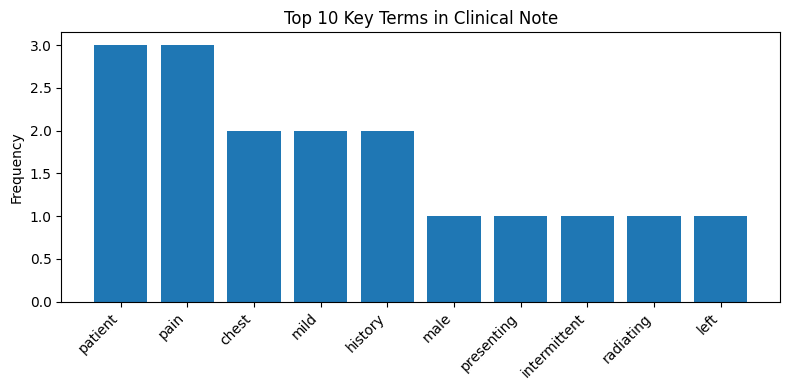

In [ ]:
print("PART 3: TEXTUAL DATA - SYNTHETIC CLINICAL NOTE")
print("="*70)

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import string

clinical_note = """
Patient is a 58-year-old male presenting with intermittent chest pain
radiating to the left arm, associated with shortness of breath and
mild diaphoresis. Pain worsens with exertion and improves with rest.
Patient reports a history of hypertension and high cholesterol.
No prior history of myocardial infarction. ECG shows mild ST depression.
Resting blood pressure is elevated at 145/92 mmHg. Patient advised
to undergo further cardiac evaluation including stress test and
lipid panel. Chest pain is suspected to be exertional angina.
"""

print("\nOriginal clinical note:")
print(clinical_note.strip())

tokens = word_tokenize(clinical_note.lower())
tokens = [t for t in tokens if t not in string.punctuation]

stop_words = set(stopwords.words("english"))
filtered_tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

print(f"\nTotal tokens (raw): {len(tokens)}")
print(f"Tokens after stopword/punctuation removal: {len(filtered_tokens)}")

word_freq = Counter(filtered_tokens)
print("\nTop 10 key terms (word frequency):")
for word, freq in word_freq.most_common(10):
    print(f"  {word:15s} : {freq}")

plt.figure(figsize=(8, 4))
words, counts = zip(*word_freq.most_common(10))
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Key Terms in Clinical Note")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


PART 4: IMAGE DATA - SAMPLE DICOM MEDICAL IMAGE

DICOM Metadata:
  Modality      : CT
  Patient ID    : 1CT1
  Rows x Columns: 128 x 128
  Pixel Spacing : [0.661468, 0.661468]
  Bits Allocated: 16


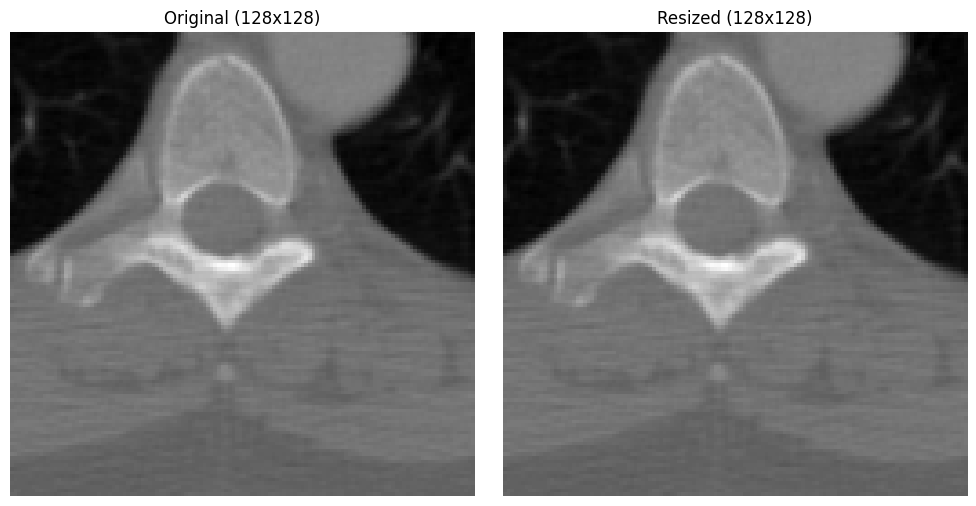

In [ ]:
print("PART 4: IMAGE DATA - SAMPLE DICOM MEDICAL IMAGE")
print("="*70)

import pydicom
from pydicom.data import get_testdata_file
from PIL import Image

dicom_path = get_testdata_file("CT_small.dcm")
ds = pydicom.dcmread(dicom_path)

print("\nDICOM Metadata:")
print(f"  Modality      : {ds.get('Modality', 'N/A')}")
print(f"  Patient ID    : {ds.get('PatientID', 'N/A')}")
print(f"  Rows x Columns: {ds.Rows} x {ds.Columns}")
print(f"  Pixel Spacing : {ds.get('PixelSpacing', 'N/A')}")
print(f"  Bits Allocated: {ds.get('BitsAllocated', 'N/A')}")

pixel_array = ds.pixel_array.astype(np.float32)
normalized = (pixel_array - pixel_array.min()) / (pixel_array.max() - pixel_array.min()) * 255
image_8bit = normalized.astype(np.uint8)

pil_image = Image.fromarray(image_8bit)
resized_image = pil_image.resize((128, 128))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(pil_image, cmap="gray")
axes[0].set_title(f"Original ({pil_image.size[0]}x{pil_image.size[1]})")
axes[0].axis("off")
axes[1].imshow(resized_image, cmap="gray")
axes[1].set_title(f"Resized ({resized_image.size[0]}x{resized_image.size[1]})")
axes[1].axis("off")
plt.tight_layout()
plt.show()
